# Encoder-Decoder LSTM Proxy Model for Reservoir Simulation
## Physics-Aware Deep Learning | Final Project — ML2, University of Chicago

**Architecture & Fixes Included:**
1. **Encoder-Decoder:** 6 static inputs (Encoder) → Latent Context → 8 output curves over time (Decoder).
2. **Correct Data Splitting (No Leakage):** Scalers are fitted strictly on the Training set indices *before* transforming the Val/Test sets.
3. **Sample Weights (Padding Fix):** Sequences are padded to equal lengths, but a binary `sample_weight` mask is passed to `model.fit()` so the MSE loss completely ignores the padded zeros.
4. **Adaptive Inference Grid:** For new scenarios, inference uses the "Average Historical Time Grid" (derived from the training set) instead of a perfectly uniform grid, keeping the LSTM in its natural distribution.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers
import joblib, os, warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow : {tf.__version__}")


TensorFlow : 2.20.0


In [6]:
df = pd.read_csv('ml_dataset_timeseries_for_lstm.csv')
print(f"Total rows   : {len(df):,}")
print(f"Unique runs  : {df['run_id'].nunique()}")


Total rows   : 158,742
Unique runs  : 200


In [7]:
# 6 static features → Encoder
ENCODER_FEATURES = [
    'producer_bhp_psi', 'gas_inj_rate_mscf_d', 'inj_bhp_limit_psi',
    'init_prod_period_days', 'perm_multiplier', 'poro_multiplier'
]

# 8 physical outputs → Decoder
OUTPUT_TARGETS = [
    'fgir', 'fgit', 'fgpr', 'fgpt', 'fopr', 'fopt', 'fpr', 'wbhp_inj'
]
TARGET_UNITS = ['MSCF/D', 'MSCF', 'MSCF/D', 'MSCF', 'STB/D', 'STB', 'PSIA', 'PSIA']


## Step 1 — Build Raw Sequences & Sample Weights
We extract the raw arrays first. We also build a binary `sample_weights` mask (1 for real data, 0 for padded data).


In [8]:
run_ids = sorted(df['run_id'].unique())

X_static_raw = []   # (6,) per run
X_time_raw   = []   # (T_i, 1) per run
y_raw        = []   # (T_i, 8) per run
seq_lens     = []

for rid in run_ids:
    run_df = df[df['run_id'] == rid].sort_values('time_days')
    X_static_raw.append(run_df[ENCODER_FEATURES].iloc[0].values.astype(np.float32))
    X_time_raw.append(run_df[['time_days']].values.astype(np.float32))
    y_raw.append(run_df[OUTPUT_TARGETS].values.astype(np.float32))
    seq_lens.append(len(run_df))

seq_lens = np.array(seq_lens)
MAX_LEN  = int(seq_lens.max())

# Build binary sample weights for the loss function
sample_weights_raw = np.zeros((len(run_ids), MAX_LEN), dtype=np.float32)
for i, length in enumerate(seq_lens):
    sample_weights_raw[i, :length] = 1.0

print(f"Max sequence length (MAX_LEN): {MAX_LEN}")


Max sequence length (MAX_LEN): 848


## Step 2 — Train/Val/Test Split
To prevent data leakage, we split the indices first. Scalers will only see the Train indices.


In [9]:
indices = np.arange(len(run_ids))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f"Train runs: {len(idx_train)} | Val runs: {len(idx_val)} | Test runs: {len(idx_test)}")


Train runs: 140 | Val runs: 30 | Test runs: 30


## Step 3 — Fit Scalers on Train, Transform All, & Pad


In [10]:
# 1. Gather flat training data to fit scalers
train_X_static = np.stack([X_static_raw[i] for i in idx_train], axis=0)
train_X_time   = np.vstack([X_time_raw[i] for i in idx_train])
train_y        = np.vstack([y_raw[i] for i in idx_train])

scaler_static = MinMaxScaler()
scaler_time   = MinMaxScaler()
scaler_y      = StandardScaler()

scaler_static.fit(train_X_static)
scaler_time.fit(train_X_time)
scaler_y.fit(train_y)

# 2. Scale all runs
X_static_s = scaler_static.transform(np.stack(X_static_raw, axis=0))
X_time_s   = [scaler_time.transform(t) for t in X_time_raw]
y_s        = [scaler_y.transform(y) for y in y_raw]

# 3. Pad sequences
# Pad with -1 sentinel — MinMaxScaler maps real time to [0,1] so -1 is never a real value
# Prevents LSTM from confusing padded steps with t=0 of the simulation
def pad_to_maxlen(arrays, max_len, n_feat):
    out = np.full((len(arrays), max_len, n_feat), -1.0, dtype=np.float32)
    for i, arr in enumerate(arrays):
        out[i, :len(arr), :] = arr
    return out

X_time_padded = pad_to_maxlen(X_time_s, MAX_LEN, 1)
y_padded      = pad_to_maxlen(y_s,      MAX_LEN, len(OUTPUT_TARGETS))

# 4. Final Data Arrays based on split indices
X_static_train, X_time_train, y_train, sw_train = X_static_s[idx_train], X_time_padded[idx_train], y_padded[idx_train], sample_weights_raw[idx_train]
X_static_val,   X_time_val,   y_val,   sw_val   = X_static_s[idx_val],   X_time_padded[idx_val],   y_padded[idx_val],   sample_weights_raw[idx_val]
X_static_test,  X_time_test,  y_test,  sw_test  = X_static_s[idx_test],  X_time_padded[idx_test],  y_padded[idx_test],  sample_weights_raw[idx_test]


In [11]:
# Weighted Huber loss
# ORDER matches OUTPUT_TARGETS: fgir fgit fgpr fgpt fopr fopt fpr wbhp_inj
LOSS_WEIGHTS = tf.constant([1.0, 1.0, 1.0, 1.0, 1.0, 1.5, 1.5, 1.0], dtype=tf.float32)

def weighted_huber(y_true, y_pred):
    # Compute element-wise absolute error then apply Huber threshold manually
    # This keeps shape (batch, timesteps, 8) — one value per variable per step
    error = tf.abs(y_true - y_pred)
    delta = 1.0
    per_element = tf.where(error <= delta,
                           0.5 * tf.square(error),
                           delta * (error - 0.5 * delta))  # shape: (batch, timesteps, 8)
    weighted = per_element * LOSS_WEIGHTS                   # broadcast over (batch, timesteps, 8)
    return tf.reduce_mean(weighted)

def build_encoder_decoder(max_len, n_static, n_outputs, latent_dim=128):
    static_input = keras.Input(shape=(n_static,), name='encoder_input')
    x = layers.Dense(64, activation='linear')(static_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dense(128, activation='linear')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    enc_h1 = layers.Dense(latent_dim, activation='tanh', name='enc_h1')(x)
    enc_c1 = layers.Dense(latent_dim, activation='tanh', name='enc_c1')(x)
    enc_h2 = layers.Dense(latent_dim // 2, activation='tanh', name='enc_h2')(x)
    enc_c2 = layers.Dense(latent_dim // 2, activation='tanh', name='enc_c2')(x)

    time_input = keras.Input(shape=(max_len, 1), name='decoder_time_input')

    # Masking layer: tells LSTM to completely skip any timestep where
    # ALL features equal the pad sentinel (-1.0). This protects the
    # hidden state from being corrupted by the padded steps.
    masked_time = layers.Masking(mask_value=-1.0, name='padding_mask')(time_input)

    dec1 = layers.LSTM(latent_dim, return_sequences=True, name='decoder_lstm1')(masked_time, initial_state=[enc_h1, enc_c1])
    dec1 = layers.Dropout(0.2)(dec1)

    dec2 = layers.LSTM(latent_dim // 2, return_sequences=True, name='decoder_lstm2')(dec1, initial_state=[enc_h2, enc_c2])
    dec2 = layers.Dropout(0.1)(dec2)

    output = layers.TimeDistributed(layers.Dense(n_outputs, activation='linear'), name='output')(dec2)

    return keras.Model(inputs=[static_input, time_input], outputs=output)

model = build_encoder_decoder(MAX_LEN, len(ENCODER_FEATURES), len(OUTPUT_TARGETS), latent_dim=256)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=weighted_huber,
    metrics=['mae']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        448 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_time_input  │ (None, 848, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 848, 1)    │          0 │ decoder_time_inp… │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_h1 (Dense)      │ (None, 256)       │     33,024 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1 (Dense)      │ (None, 256)       │     33,024 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm1       │ (None, 848, 256)  │    264,192 │ padding_mask[0][… │
│ (LSTM)              │                   │            │ enc_h1[0][0],     │
│                     │                   │            │ enc_c1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 848, 256)  │          0 │ decoder_lstm1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_h2 (Dense)      │ (None, 128)       │     16,512 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c2 (Dense)      │ (None, 128)       │     16,512 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm2       │ (None, 848, 128)  │    197,120 │ dropout[0][0],    │
│ (LSTM)              │                   │            │ enc_h2[0][0],     │
│                     │                   │            │ enc_c2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 848, 1)    │          0 │ decoder_time_inp… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 848, 128)  │          0 │ decoder_lstm2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 848)       │          0 │ not_equal[0][0] 

 Total params: 570,952 (2.18 MB)

 Trainable params: 570,568 (2.18 MB)

 Non-trainable params: 384 (1.50 KB)

## Step 4 — Train with `sample_weight`
The `sample_weight` array ensures the MSE loss completely ignores the `0.0` padded timesteps.


In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=40,              # increased from 30: physics curves converge slowly
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

history = model.fit(
    [X_static_train, X_time_train],
    y_train,
    sample_weight=sw_train,        # <--- IGNORING PADDED ZEROS
    validation_data=(
        [X_static_val, X_time_val],
        y_val,
        sw_val                     # <--- IGNORING PADDED ZEROS IN VAL
    ),
    epochs=300, batch_size=8, callbacks=callbacks, verbose=1
)


Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 51s 696ms/step - loss: 0.3287 - mae: 0.5575 - val_loss: 0.2803 - val_mae: 0.4587 - learning_rate: 0.0010
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - loss: 0.1842 - mae: 0.3434 - val_loss: 0.2187 - val_mae: 0.3963 - learning_rate: 0.0010
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - loss: 0.1689 - mae: 0.3326 - val_loss: 0.2050 - val_mae: 0.3767 - learning_rate: 0.0010
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - loss: 0.1564 - mae: 0.3198 - val_loss: 0.2118 - val_mae: 0.4258 - learning_rate: 0.0010
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.1513 - mae: 0.3298 - val_loss: 0.1464 - val_mae: 0.3193 - learning_rate: 0.0010
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - loss: 0.1493 - mae: 0.3254 - val_loss: 0.1509 - val_mae: 0.3298 - learning_rate: 0.0010
Epoch 7/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - loss: 0.1446 - mae: 0.3120 - val_loss: 0.1387 - val_mae: 0.2981 - learning_rate: 0.001

## Step 5 — Training Curves
Visualizing loss and MAE ensures the model converges properly and does not overfit.


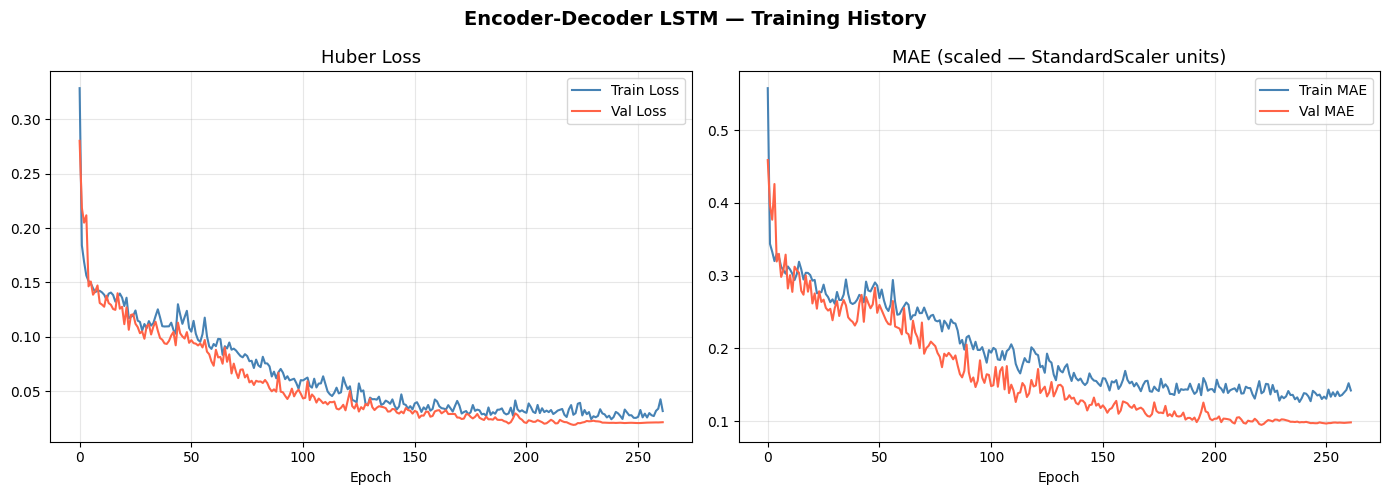

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato')
axes[0].set_title('Huber Loss', fontsize=13); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='tomato')
axes[1].set_title('MAE (scaled — StandardScaler units)', fontsize=13); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Encoder-Decoder LSTM — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [14]:
# Predict on Test Set
y_pred_s = model.predict([X_static_test, X_time_test], verbose=0)
n_test, T, n_out = y_pred_s.shape

y_pred_real = scaler_y.inverse_transform(y_pred_s.reshape(-1, n_out)).reshape(n_test, T, n_out)
y_true_real = scaler_y.inverse_transform(y_test.reshape(-1, n_out)).reshape(n_test, T, n_out)

print("=" * 68)
print(f"{'Target':<12} | {'R²':>8} | {'MAE':>14} | {'Unit'}")
print("-" * 68)

for i, (tgt, unit) in enumerate(zip(OUTPUT_TARGETS, TARGET_UNITS)):
    # Flatten and use sample_weight mask to drop padded timesteps from metrics
    true_flat = y_true_real[:, :, i].flatten()
    pred_flat = y_pred_real[:, :, i].flatten()
    mask = sw_test.flatten() == 1.0  # ONLY REAL TIMESTEPS

    r2  = r2_score(true_flat[mask], pred_flat[mask])
    mae = mean_absolute_error(true_flat[mask], pred_flat[mask])
    print(f"{tgt:<12} | {r2:>8.4f} | {mae:>14,.2f} | {unit}")


Target       |       R² |            MAE | Unit
--------------------------------------------------------------------
fgir         |   0.9466 |           1.09 | MSCF/D
fgit         |   0.9906 |       4,655.81 | MSCF
fgpr         |   0.9511 |           1.09 | MSCF/D
fgpt         |   0.9895 |       4,664.54 | MSCF
fopr         |   0.9838 |           3.98 | STB/D
fopt         |   0.9650 |       1,976.06 | STB
fpr          |   0.8421 |         248.63 | PSIA
wbhp_inj     |   0.9199 |         302.36 | PSIA


## Step 6 — Visual Verification: Predicted vs Actual Curves
Visually proves the model learned the physical shape of the curves for unseen test runs, not just a single scalar value.


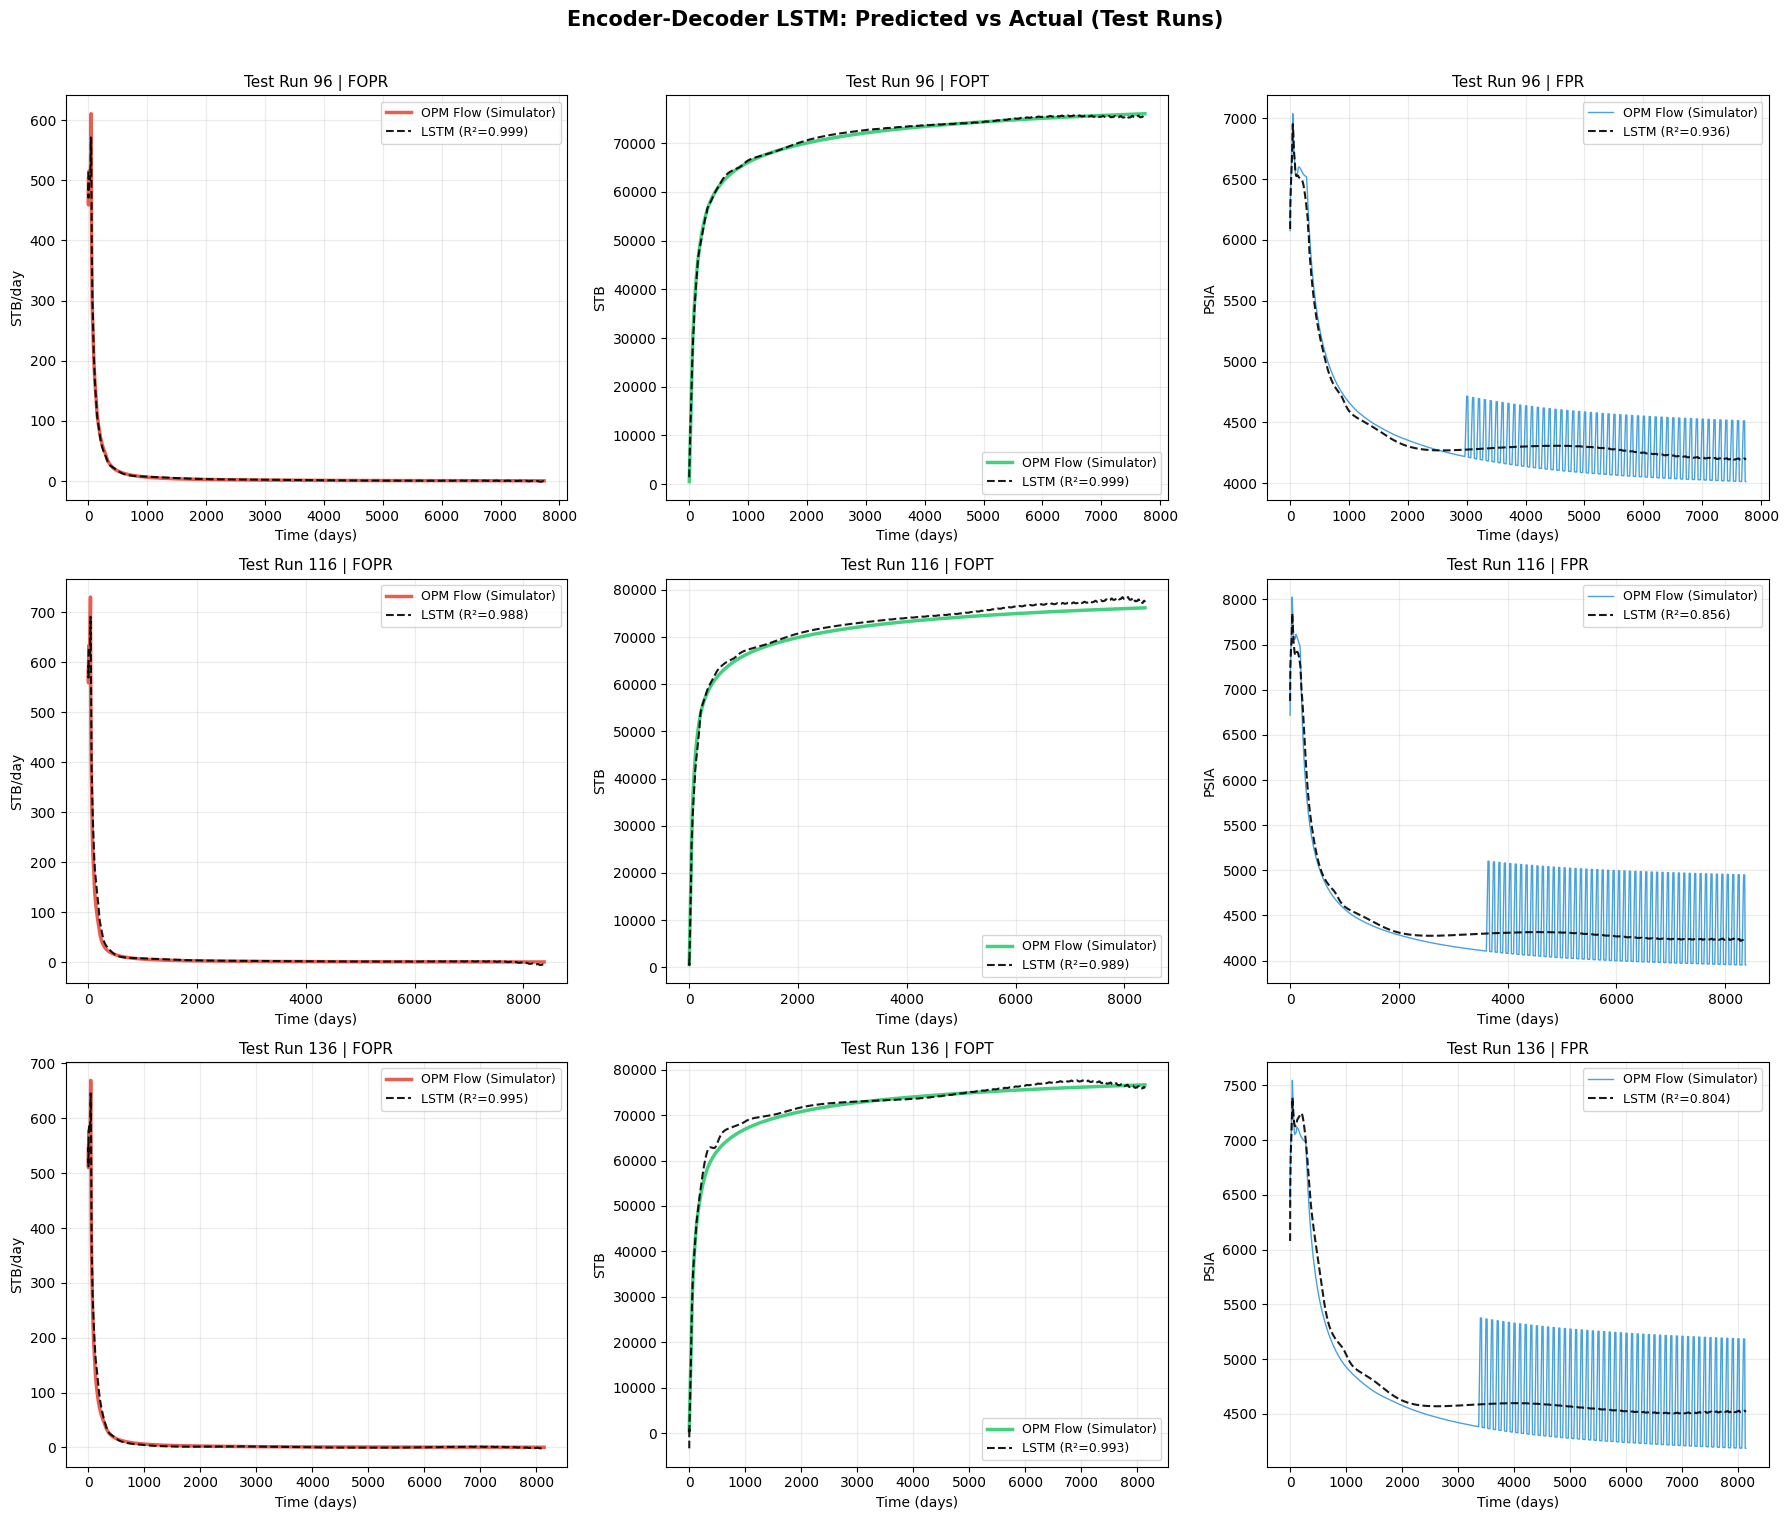

In [15]:
PRIMARY    = ['fopr', 'fopt', 'fpr']
PRIM_IDX   = [OUTPUT_TARGETS.index(t) for t in PRIMARY]
PRIM_UNITS = ['STB/day', 'STB', 'PSIA']
COLORS     = ['#e74c3c', '#2ecc71', '#3498db']

n_plot = min(3, n_test)
fig, axes = plt.subplots(n_plot, 3, figsize=(18, 5 * n_plot))
fig.suptitle('Encoder-Decoder LSTM: Predicted vs Actual (Test Runs)', fontsize=15, fontweight='bold', y=1.01)

for row in range(n_plot):
    # Recover real time axis for this run (ignoring padded steps)
    run_len = int(np.sum(sw_test[row]))
    time_real = scaler_time.inverse_transform(X_time_test[row, :run_len, :]).flatten()

    for col, (tgt_name, tgt_i, unit, color) in enumerate(zip(PRIMARY, PRIM_IDX, PRIM_UNITS, COLORS)):
        ax = axes[row, col] if n_plot > 1 else axes[col]

        true_vals = y_true_real[row, :run_len, tgt_i]
        pred_vals = y_pred_real[row, :run_len, tgt_i]
        r2 = r2_score(true_vals, pred_vals)

        lw = 1.0 if tgt_name == 'fpr' else 2.5
        ax.plot(time_real, true_vals, color=color, linewidth=lw, label='OPM Flow (Simulator)', alpha=0.9)

        ax.plot(time_real, pred_vals, color='black', linewidth=1.5, linestyle='--', label=f'LSTM (R²={r2:.3f})', alpha=0.9)

        ax.set_title(f'Test Run {idx_test[row]+1} | {tgt_name.upper()}', fontsize=11)
        ax.set_xlabel('Time (days)'); ax.set_ylabel(f'{unit}')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## Step 7 — Inference with Average Historical Grid
Instead of an arbitrary uniform grid, we calculate the average adaptive time-stepping behavior of the simulator from the training set.


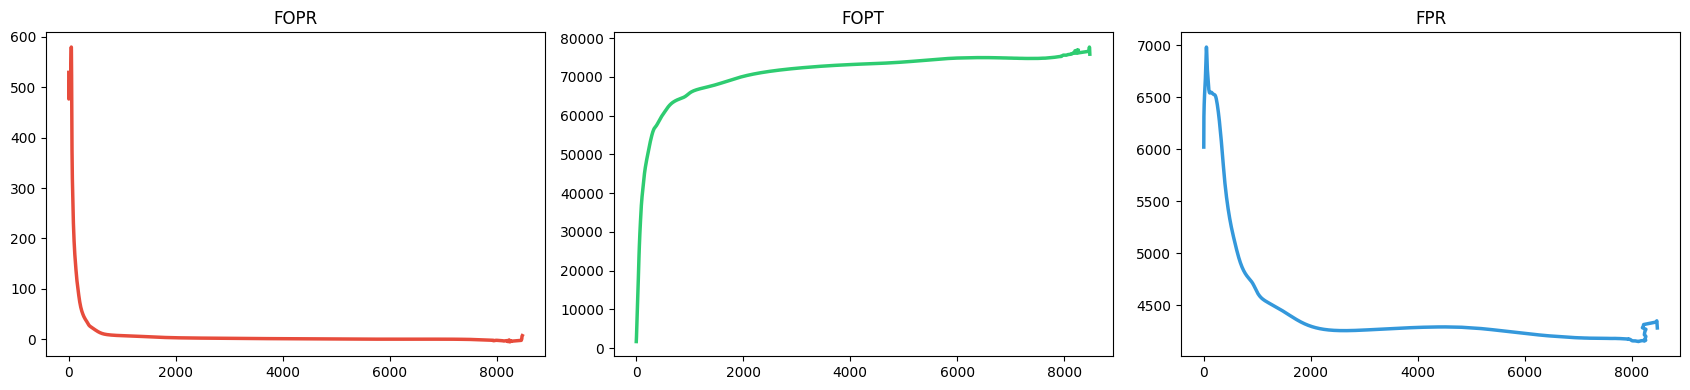

['saved_models/scaler_y.pkl']

In [16]:
# Calculate the average historical adaptive grid from the training set
avg_time_grid = np.zeros(MAX_LEN, dtype=np.float32)
for step in range(MAX_LEN):
    vals = [X_time_raw[i][step, 0] for i in idx_train if step < len(X_time_raw[i])]
    avg_time_grid[step] = np.mean(vals) if vals else avg_time_grid[step-1]

new_scenario = pd.DataFrame([{
    'producer_bhp_psi': 3000, 'gas_inj_rate_mscf_d': 35.0, 'inj_bhp_limit_psi': 10000,
    'init_prod_period_days': 3230, 'perm_multiplier': 1.0, 'poro_multiplier': 1.0
}])

X_new_static = scaler_static.transform(new_scenario[ENCODER_FEATURES].values)
X_new_time   = scaler_time.transform(avg_time_grid.reshape(-1, 1)).reshape(1, MAX_LEN, 1)

y_new_s = model.predict([X_new_static, X_new_time], verbose=0)
y_new   = scaler_y.inverse_transform(y_new_s.reshape(-1, len(OUTPUT_TARGETS))).reshape(MAX_LEN, len(OUTPUT_TARGETS))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, tgt_name, color in zip(axes, ['fopr', 'fopt', 'fpr'], ['#e74c3c', '#2ecc71', '#3498db']):
    tgt_i = OUTPUT_TARGETS.index(tgt_name)
    ax.plot(avg_time_grid, y_new[:, tgt_i], color=color, linewidth=2.5)
    ax.set_title(f'{tgt_name.upper()}')
plt.tight_layout()
plt.show()

# Save models/scalers
os.makedirs('saved_models', exist_ok=True)
model.save('saved_models/enc_dec_lstm_reservoir_proxy.keras')
joblib.dump(scaler_static, 'saved_models/scaler_static.pkl')
joblib.dump(scaler_time,   'saved_models/scaler_time.pkl')
joblib.dump(scaler_y,      'saved_models/scaler_y.pkl')
